# Linear Regression — Complete End-to-End Machine Learning Project

This notebook demonstrates **Linear Regression from EDA to performance evaluation**.

## Workflow
1. Import libraries
2. Load dataset
3. Understand the data
4. EDA
5. Data cleaning
6. Outlier analysis
7. Feature-target separation
8. Train-test split
9. Feature scaling
10. Train Linear Regression
11. Predictions
12. Performance metrics
13. Residual analysis
14. Coefficient interpretation
15. Model saving

In [3]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Load the Dataset

We will use the **California Housing Dataset** provided by scikit-learn.

The goal is to predict `MedHouseVal`, the median house value, using the remaining features.

In [4]:
# Load California Housing dataset

housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325,41.000,6.984,1.024,322.000,2.556,37.880,-122.230,4.526
1,8.301,21.000,6.238,0.972,2401.000,2.110,37.860,-122.220,3.585
2,7.257,52.000,8.288,1.073,496.000,2.802,37.850,-122.240,3.521
3,5.643,52.000,5.817,1.073,558.000,2.548,37.850,-122.250,3.413
4,3.846,52.000,6.282,1.081,565.000,2.181,37.850,-122.250,3.422


## 3. Understand the Dataset

In [5]:
# Dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 9


In [6]:
# Column names

df.columns.tolist()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

In [7]:
# First 10 rows

df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325,41.000,6.984,1.024,322.000,2.556,37.880,-122.230,4.526
1,8.301,21.000,6.238,0.972,2401.000,2.110,37.860,-122.220,3.585
2,7.257,52.000,8.288,1.073,496.000,2.802,37.850,-122.240,3.521
3,5.643,52.000,5.817,1.073,558.000,2.548,37.850,-122.250,3.413
4,3.846,52.000,6.282,1.081,565.000,2.181,37.850,-122.250,3.422
5,4.037,52.000,4.762,1.104,413.000,2.140,37.850,-122.250,2.697
6,3.659,52.000,4.932,0.951,1094.000,2.128,37.840,-122.250,2.992
7,3.120,52.000,4.798,1.062,1157.000,1.788,37.840,-122.250,2.414
8,2.080,42.000,4.294,1.118,1206.000,2.027,37.840,-122.260,2.267
9,3.691,52.000,4.971,0.990,1551.000,2.172,37.840,-122.250,2.611


In [8]:
# Random sample

df.sample(5, random_state=42)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.681,25.000,4.192,1.022,1392.000,3.877,36.060,-119.010,0.477
3024,2.531,30.000,5.039,1.193,1565.000,2.680,35.140,-119.460,0.458
15663,3.480,52.000,3.977,1.186,1310.000,1.360,37.800,-122.440,5.000
20484,5.738,17.000,6.164,1.020,1705.000,3.444,34.280,-118.720,2.186
9814,3.725,34.000,5.493,1.028,1063.000,2.484,36.620,-121.930,2.780


In [9]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.000,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.000,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.000,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.000,2.069,1.154,0.150,1.196,1.797,2.647,5.000


In [11]:
# Data types

df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand:
- Distribution of variables
- Missing values
- Duplicate records
- Outliers
- Correlations
- Relationship between features and target

In [12]:
# Check missing values

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing

,Missing Values,Missing Percentage
MedInc,0,0.000
HouseAge,0,0.000
AveRooms,0,0.000
AveBedrms,0,0.000
Population,0,0.000
AveOccup,0,0.000
Latitude,0,0.000
Longitude,0,0.000
MedHouseVal,0,0.000


In [13]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Number of unique values

df.nunique().sort_values()

HouseAge          52
Longitude        844
Latitude         862
MedHouseVal     3842
Population      3888
MedInc         12928
AveBedrms      14233
AveOccup       18841
AveRooms       19392
dtype: int64

### 4.1 Distribution of All Numerical Features

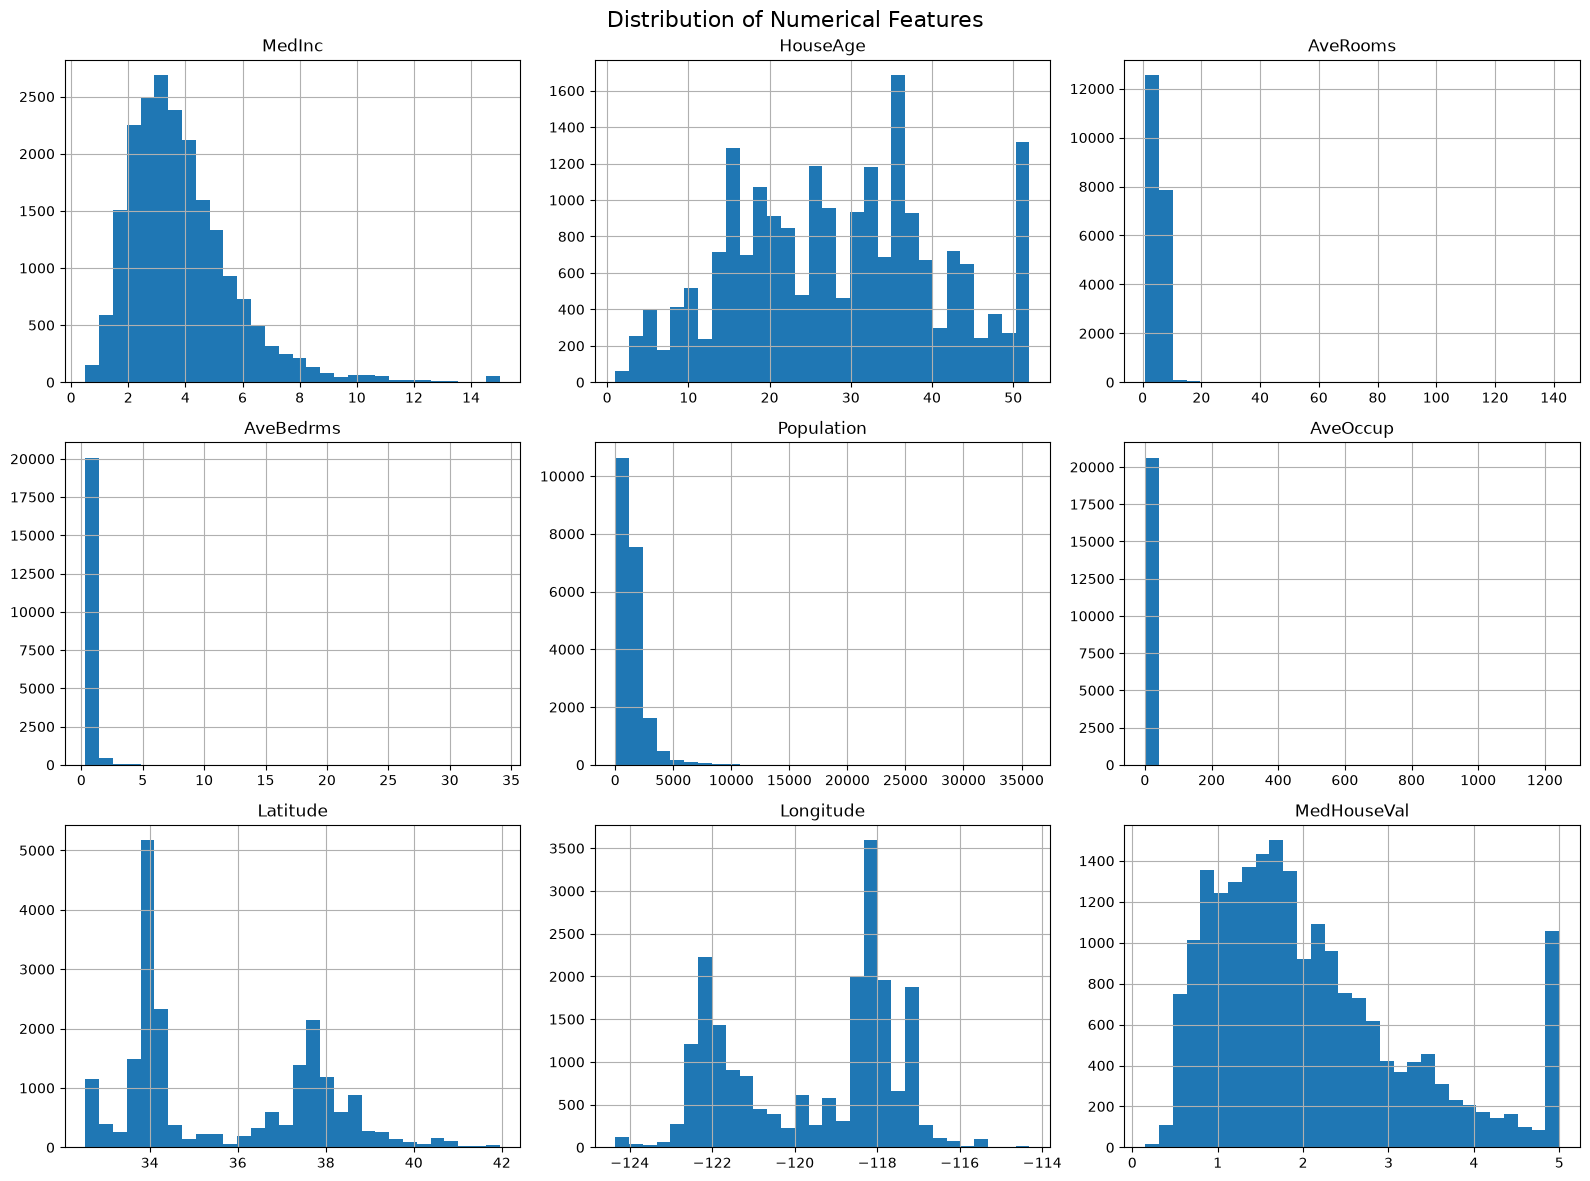

In [15]:
# Histograms

df.hist(figsize=(16, 12), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### 4.2 Target Variable Distribution

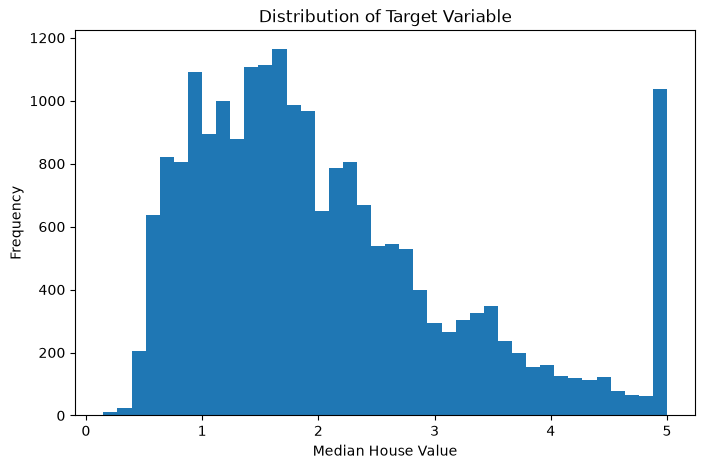

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=40)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")

plt.show()

### 4.3 Boxplots — Outlier Detection

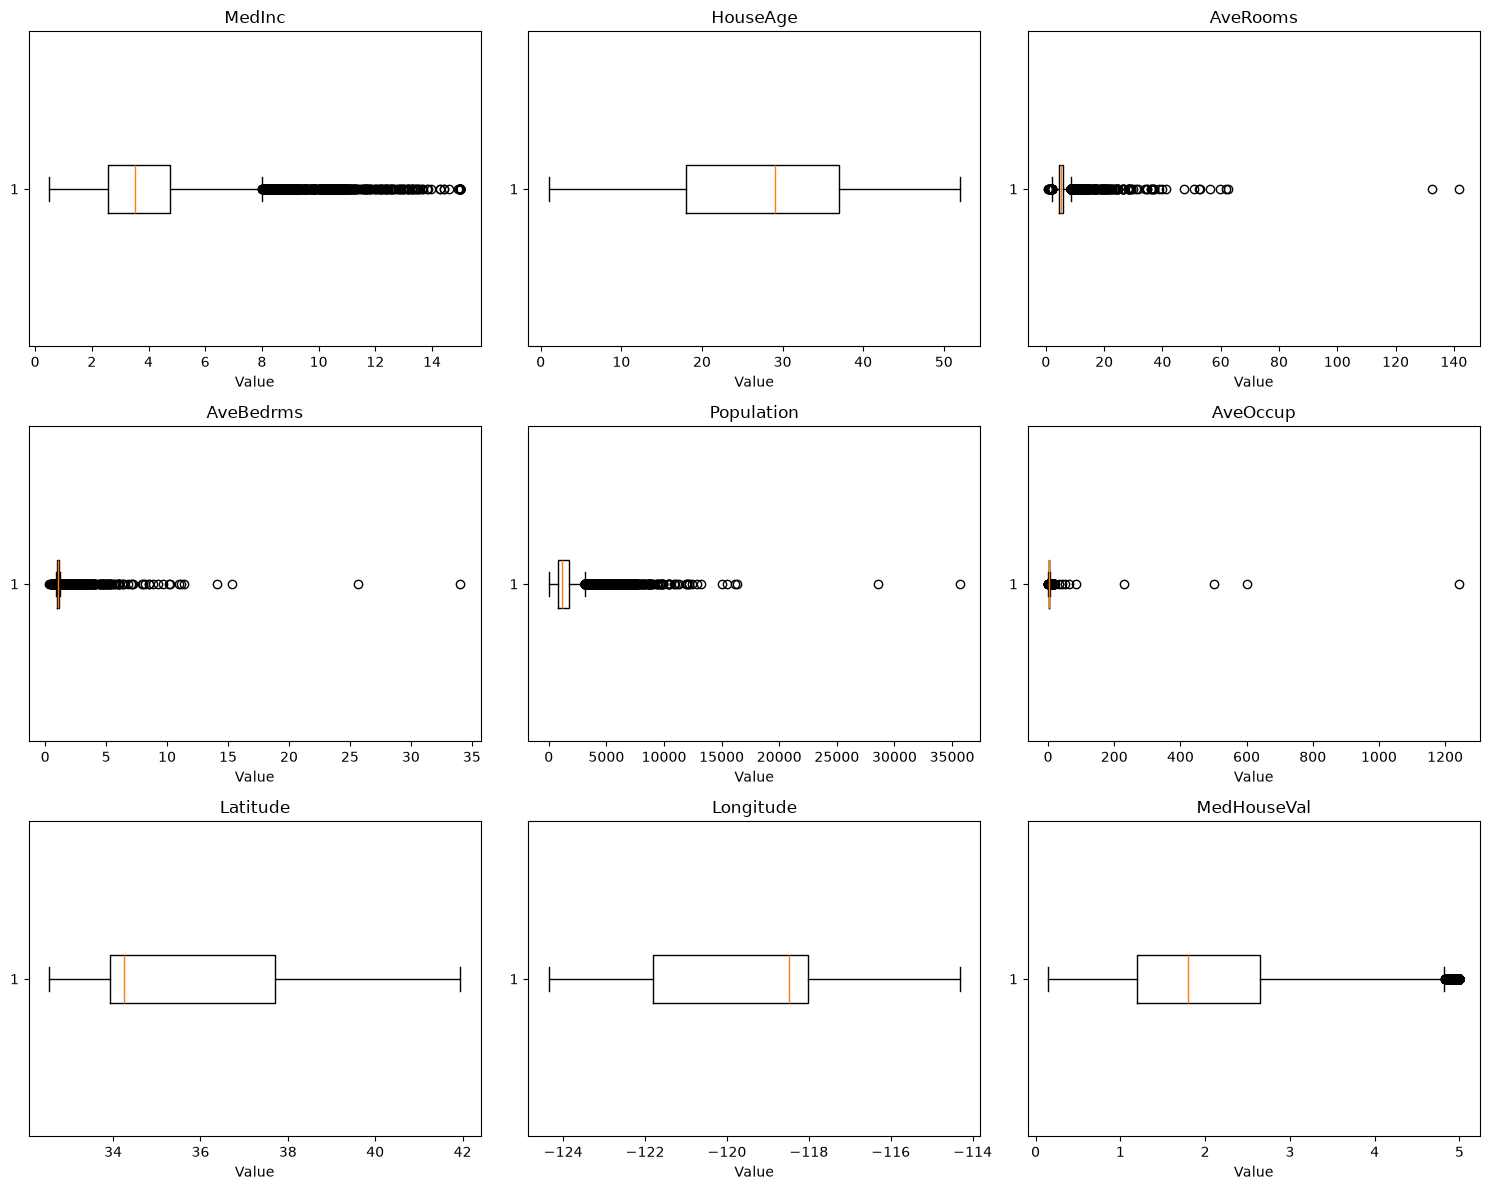

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    axes[i].boxplot(df[column].dropna(), vert=False)
    axes[i].set_title(column)
    axes[i].set_xlabel("Value")

for i in range(len(df.columns), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 4.4 Correlation Analysis

Correlation tells us how strongly two numerical variables are linearly related.

- +1 → strong positive relationship
- 0 → no linear relationship
- -1 → strong negative relationship

In [18]:
# Correlation matrix

correlation = df.corr(numeric_only=True)

correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000,-0.119,0.327,-0.062,0.005,0.019,-0.080,-0.015,0.688
HouseAge,-0.119,1.000,-0.153,-0.078,-0.296,0.013,0.011,-0.108,0.106
AveRooms,0.327,-0.153,1.000,0.848,-0.072,-0.005,0.106,-0.028,0.152
AveBedrms,-0.062,-0.078,0.848,1.000,-0.066,-0.006,0.070,0.013,-0.047
Population,0.005,-0.296,-0.072,-0.066,1.000,0.070,-0.109,0.100,-0.025
AveOccup,0.019,0.013,-0.005,-0.006,0.070,1.000,0.002,0.002,-0.024
Latitude,-0.080,0.011,0.106,0.070,-0.109,0.002,1.000,-0.925,-0.144
Longitude,-0.015,-0.108,-0.028,0.013,0.100,0.002,-0.925,1.000,-0.046
MedHouseVal,0.688,0.106,0.152,-0.047,-0.025,-0.024,-0.144,-0.046,1.000


In [19]:
# Correlation with target

target_correlation = (
    correlation["MedHouseVal"]
    .sort_values(ascending=False)
)

target_correlation

MedHouseVal    1.000
MedInc         0.688
AveRooms       0.152
HouseAge       0.106
AveOccup      -0.024
Population    -0.025
Longitude     -0.046
AveBedrms     -0.047
Latitude      -0.144
Name: MedHouseVal, dtype: float64

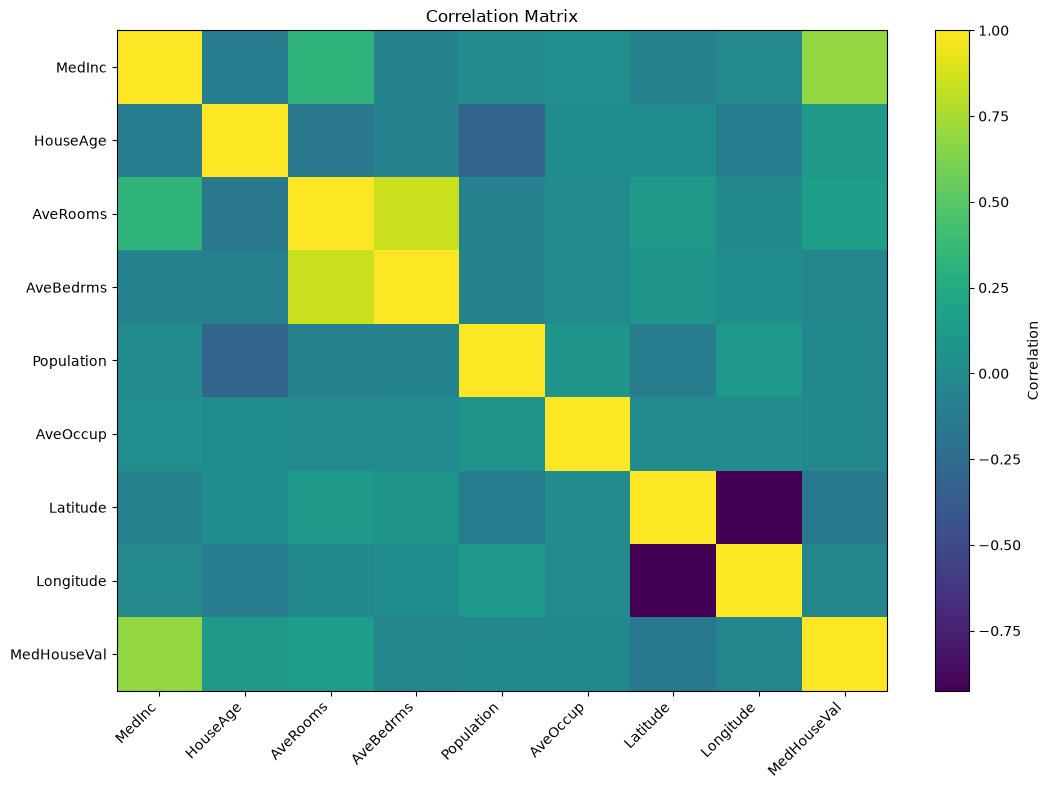

In [20]:
# Correlation heatmap using matplotlib

plt.figure(figsize=(11, 8))

plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Visualization

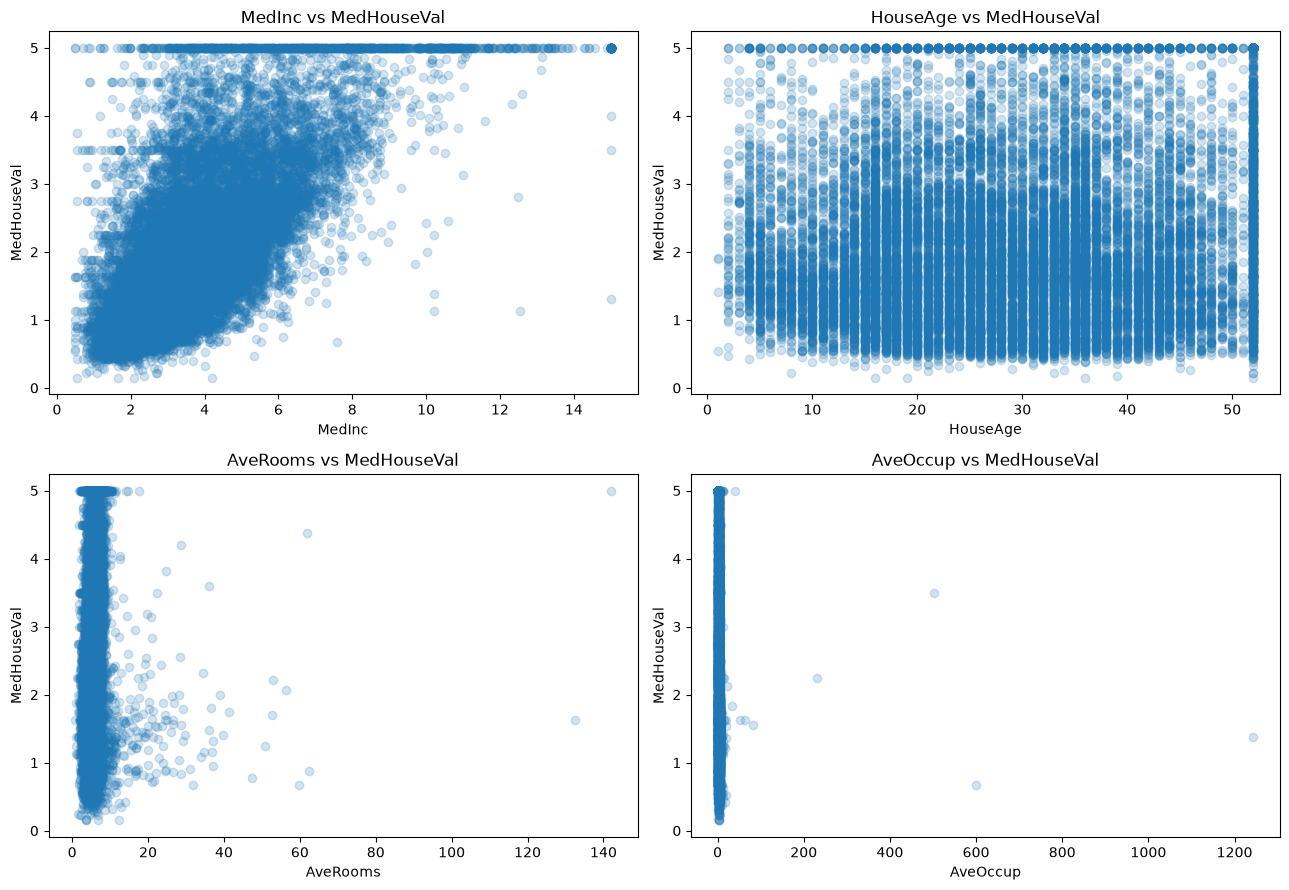

In [21]:
features_to_plot = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveOccup"
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):
    ax.scatter(
        df[feature],
        df["MedHouseVal"],
        alpha=0.2
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("MedHouseVal")
    ax.set_title(f"{feature} vs MedHouseVal")

plt.tight_layout()
plt.show()

## 5. Data Cleaning

Before modeling, we check:
- Missing values
- Duplicate rows
- Invalid values
- Outliers

This dataset does not contain missing values. We will remove duplicate rows if any exist.

In [22]:
# Remove duplicate rows

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Duplicates removed:", before - after)

Rows before cleaning: 20640
Rows after cleaning: 20640
Duplicates removed: 0


In [23]:
# Confirm missing values

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [24]:
# Check negative values

numeric_columns = df.select_dtypes(include=np.number).columns

negative_values = (df[numeric_columns] < 0).sum()

negative_values

MedInc             0
HouseAge           0
AveRooms           0
AveBedrms          0
Population         0
AveOccup           0
Latitude           0
Longitude      20640
MedHouseVal        0
dtype: int64

## 6. Outlier Analysis Using IQR

The IQR method defines:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

We inspect outliers rather than automatically deleting them.

In [25]:
def count_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((series < lower) | (series > upper)).sum()

outlier_counts = {}

for column in numeric_columns:
    outlier_counts[column] = count_iqr_outliers(df[column])

outlier_table = (
    pd.Series(outlier_counts, name="Outlier Count")
    .sort_values(ascending=False)
)

outlier_table

AveBedrms      1424
Population     1196
MedHouseVal    1071
AveOccup        711
MedInc          681
AveRooms        511
HouseAge          0
Latitude          0
Longitude         0
Name: Outlier Count, dtype: int64

## 7. Separate Features and Target

`X` contains the independent variables.

`y` contains the dependent variable that we want to predict.

In [26]:
# Features and target

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (20640, 8)
Target shape: (20640,)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 8. Train-Test Split

We divide the dataset into:

- **80% training data**
- **20% testing data**

The model learns only from the training data. The test data remains unseen until evaluation.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


## 9. Feature Scaling

We use `StandardScaler`.

Formula:

**z = (x − mean) / standard deviation**

Important: the scaler is fitted only on training data to prevent data leakage.

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (16512, 8)
Scaled testing shape: (4128, 8)


In [29]:
# Verify scaling

print("Training means:")
print(X_train_scaled.mean(axis=0).round(3))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0).round(3))

Training means:
[-0. -0.  0. -0.  0.  0.  0.  0.]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1.]


## 10. Train Linear Regression

Linear Regression tries to learn:

**y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ**

where:
- β₀ = intercept
- β₁...βₙ = coefficients
- x = input features
- y = prediction

In [30]:
# Create model

model = LinearRegression()

# Train model

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [31]:
# Model intercept

print("Intercept:", model.intercept_)

Intercept: 2.071946937378881


## 11. Model Coefficients

Because the features were standardized, the coefficients represent the effect of approximately one standard deviation change in each feature, while holding other features constant.

In [32]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

,Feature,Coefficient,Absolute Coefficient
6,Latitude,-0.897,0.897
7,Longitude,-0.870,0.870
0,MedInc,0.854,0.854
3,AveBedrms,0.339,0.339
2,AveRooms,-0.294,0.294
1,HouseAge,0.123,0.123
5,AveOccup,-0.041,0.041
4,Population,-0.002,0.002


## 12. Make Predictions

In [33]:
# Predictions on training and testing data

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


In [34]:
# Compare actual and predicted values

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

prediction_df.head(10)

,Actual,Predicted
0,0.477,0.719
1,0.458,1.764
2,5.000,2.710
3,2.186,2.839
4,2.780,2.605
5,1.587,2.012
6,1.982,2.646
7,1.575,2.169
8,3.400,2.741
9,4.466,3.916


## 13. Performance Metrics

We will use four important regression metrics:

### 1. MAE — Mean Absolute Error
Average absolute difference between actual and predicted values.

**Lower is better.**

### 2. MSE — Mean Squared Error
Average squared prediction error.

**Lower is better.**

### 3. RMSE — Root Mean Squared Error
Square root of MSE.

**Lower is better.**

### 4. R² Score
Percentage of target variance explained by the model.

**Higher is better.**

In [35]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [36]:
# Training metrics

train_mae, train_mse, train_rmse, train_r2 = calculate_metrics(
    y_train,
    y_train_pred
)

print("TRAINING PERFORMANCE")
print("--------------------")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

TRAINING PERFORMANCE
--------------------
MAE : 0.5286283596581934
MSE : 0.5179331255246699
RMSE: 0.7196757085831575
R²  : 0.6125511913966952


In [37]:
# Testing metrics

test_mae, test_mse, test_rmse, test_r2 = calculate_metrics(
    y_test,
    y_test_pred
)

print("TESTING PERFORMANCE")
print("-------------------")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

TESTING PERFORMANCE
-------------------
MAE : 0.5332001304956565
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
R²  : 0.5757877060324508


In [38]:
# Create a performance table

performance = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

performance

,Metric,Training,Testing
0,MAE,0.529,0.533
1,MSE,0.518,0.556
2,RMSE,0.720,0.746
3,R²,0.613,0.576


## 14. Actual vs Predicted Plot

The closer the points are to the diagonal line, the better the predictions.

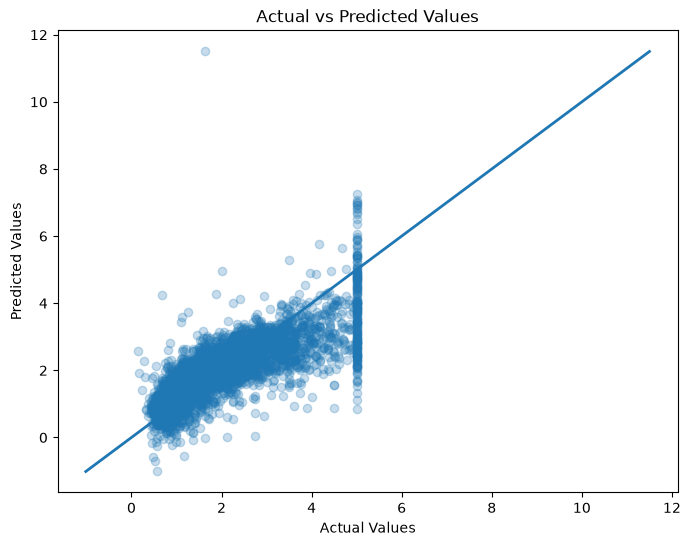

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.25
)

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

## 15. Residual Analysis

Residual:

**Residual = Actual − Predicted**

A good regression model should generally have residuals distributed around zero without a strong systematic pattern.

In [40]:
# Calculate residuals

residuals = y_test - y_test_pred

residuals.head()

20046   -0.242
3024    -1.306
15663    2.290
20484   -0.653
9814     0.175
Name: MedHouseVal, dtype: float64

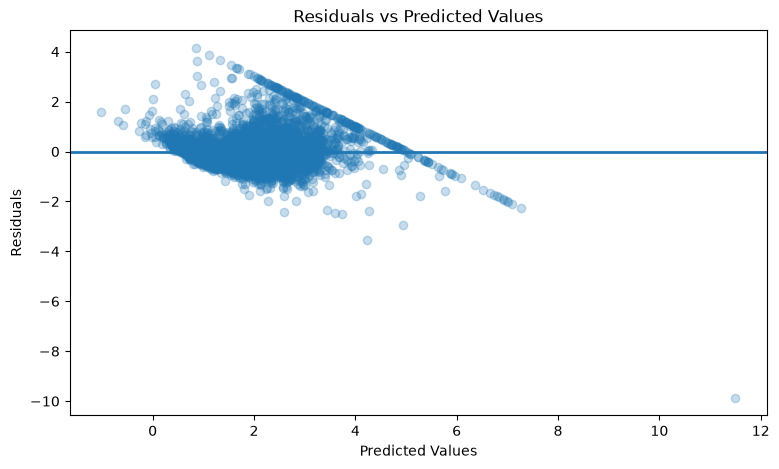

In [41]:
# Residuals vs predicted values

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.25
)

plt.axhline(
    0,
    linewidth=2
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

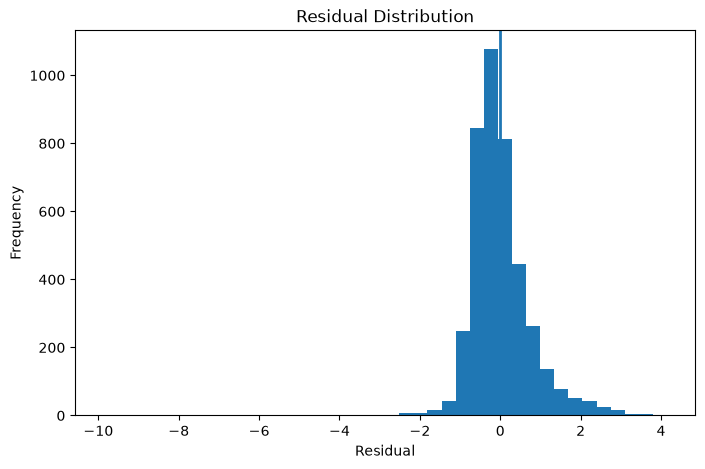

In [42]:
# Residual distribution

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=40
)

plt.axvline(
    0,
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

## 16. Error Analysis

Let's find predictions with the largest absolute errors.

In [43]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

error_analysis["Error"] = (
    error_analysis["Actual"] -
    error_analysis["Predicted"]
)

error_analysis["Absolute Error"] = (
    error_analysis["Error"].abs()
)

error_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute Error
3722,1.625,11.500,-9.875,9.875
1649,5.000,0.852,4.148,4.148
1140,5.000,1.115,3.885,3.885
872,5.000,1.320,3.680,3.680
3710,4.500,0.867,3.633,3.633
1250,0.675,4.236,-3.561,3.561
1865,5.000,1.548,3.452,3.452
1138,5.000,1.643,3.357,3.357
3693,5.000,1.668,3.332,3.332
3761,5.000,1.711,3.289,3.289


## 17. Training vs Testing Performance

Comparing training and testing performance helps identify potential overfitting.

If training performance is much better than testing performance, the model may not generalize well.

In [44]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Training": [
        train_mae,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

comparison

,Metric,Training,Testing
0,MAE,0.529,0.533
1,RMSE,0.720,0.746
2,R²,0.613,0.576


## 18. Prediction on a New Sample

The new sample must contain the same features in the same order used during training.

In [45]:
# Take one test row as an example new sample

new_sample = X_test.iloc[[0]]

print("Input:")
display(new_sample)

# Scale the new sample
new_sample_scaled = scaler.transform(new_sample)

# Predict
new_prediction = model.predict(new_sample_scaled)

print("Predicted house value:", new_prediction[0])
print("Actual house value:", y_test.iloc[0])

Input:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.681,25.000,4.192,1.022,1392.000,3.877,36.060,-119.010


Predicted house value: 0.7191228416019131
Actual house value: 0.477


## 19. Save the Model

We save both:
- The trained Linear Regression model
- The fitted StandardScaler

Both are required when making predictions on future data.

In [46]:
import joblib

model_package = {
    "model": model,
    "scaler": scaler,
    "features": list(X.columns)
}

joblib.dump(
    model_package,
    "linear_regression_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## 20. Load the Saved Model

In [47]:
# Load model package

loaded_package = joblib.load(
    "linear_regression_model.pkl"
)

loaded_model = loaded_package["model"]
loaded_scaler = loaded_package["scaler"]
loaded_features = loaded_package["features"]

print("Model loaded successfully!")
print("Features:", loaded_features)

Model loaded successfully!
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


# Final Summary

## Complete Linear Regression Pipeline

**Raw Dataset**
↓  
**Data Understanding**
↓  
**EDA**
- Shape
- Data types
- Statistics
- Missing values
- Duplicates
- Distributions
- Outliers
- Correlation
- Feature-target relationships
↓  
**Data Cleaning**
↓  
**X / y Separation**
↓  
**Train-Test Split**
↓  
**Feature Scaling**
↓  
**Linear Regression Training**
↓  
**Prediction**
↓  
**Performance Metrics**
- MAE
- MSE
- RMSE
- R²
↓  
**Residual Analysis**
↓  
**Error Analysis**
↓  
**Model Interpretation**
↓  
**Model Saving**

## Important Concepts

- Always split data before fitting preprocessing transformations.
- Never use test data to fit the scaler.
- Lower MAE/MSE/RMSE means lower prediction error.
- Higher R² generally means better explanatory performance.
- Residual plots help identify patterns that Linear Regression cannot capture.
- Linear Regression assumes a reasonably linear relationship between predictors and target.
- For better performance, compare Linear Regression with models such as Ridge, Lasso, Random Forest, and Gradient Boosting.